# CogVideoX - Generation Video depuis Texte (Open Weights)

**Module :** 02-Video-Advanced
**Niveau :** Intermediaire
**Technologies :** CogVideoX-2b (THUDM), diffusers, Apache-2.0
**Duree estimee :** 30-60 minutes
**VRAM :** ~16-20 GB

## Objectifs d'Apprentissage

- [ ] Verifier une licence de modele open-weights **firsthand** (ici Apache-2.0, pas d'Excluded Territory ni de clause Outputs)
- [ ] Charger le pipeline `CogVideoXPipeline` de diffusers
- [ ] Generer une video 6s @ 8 fps depuis un prompt texte
- [ ] Comprendre la structure 3D VAE + temporal transformer de CogVideoX
- [ ] Executer un **couple discriminant** (Prong B) pour rendre visible ce que le moteur apporte au-dela d'une suite d'images independantes
- [ ] Mesurer VRAM + wall-clock reels sur la machine de la lane

## Prerequis

- GPU avec 16+ GB VRAM (RTX 3090 24GB recommande)
- Packages : `diffusers>=0.30`, `transformers`, `torch` (CUDA 12.x), `accelerate`, `imageio`, `imageio-ffmpeg`
- Le notebook **02-6** (MiniMax H3, descriptif) qui montre ce qu'on NE peut PAS faire pour des raisons de licence

## Couplage pedagogique avec 02-6 (MiniMax H3)

La famille `02-Video-Advanced` comprend deux notebooks qui se completent :

- **[02-6](02-6-MiniMax-H3-Architecture-Licensing.ipynb)** montre *pourquoi* un modele puissant (MiniMax H3, #1 Artificial Analysis) est **hors d'atteinte** en UE/UK/Coree/USA — sa licence communautaire *MiniMax H3 Community License* exclut explicitement l'usage, l'hebergement et l'affichage des Outputs sur ces territoires (Art. I.3 + I.5 + V.4). Verdict SOTA `INTRINSIC`.
- **Ce notebook (02-7)** montre ce que la famille *peut* faire quand le modele est licite : generation video reelle sur un modele open-weights **permissif** (Apache-2.0). Le couple (descriptif INTRINSIC + executif SOTA-OK) est la valeur pedagogique — pas chaque moitie isolement.

**Navigation :** [<< 02-6](02-6-MiniMax-H3-Architecture-Licensing.ipynb) | [Index](../README.md) | [Suivant >>](../03-Orchestration/03-1-Multi-Model-Video-Comparison.ipynb)


In [1]:
# Parametres Papermill - JAMAIS modifier ce commentaire

# Configuration notebook
notebook_mode = "interactive"        # "interactive" ou "batch"
skip_widgets = False               # True pour mode batch MCP
debug_level = "INFO"

# Parametres modele (CogVideoX-2b = 2B params, Apache-2.0)
model_id = "THUDM/CogVideoX-2b"   # Open weights, Apache-2.0
device = "cuda"                    # Device de calcul (RTX 3090)
dtype = "bf16"                     # bfloat16 = meilleure stabilite numerique que fp16 sur transformers

# Parametres generation (coherents avec 02-2 LTX-Video : ~6s, 480x720)
num_frames = 49                    # 49 frames * (1/8 fps) ~= 6 secondes a 8fps (DUREE NATIVE CogVideoX-2b ; cf cell-6)
num_inference_steps = 25           # ~25 etapes = bon compromis qualite/temps
guidance_scale = 6.0               # CFG CogVideoX recommande 6.0 (vs 7.5 LTX)
height = 480                       # Resolution native
width = 720                        # Ratio 9:16 vertical
fps = 8                            # Frame rate natif CogVideoX

# Discrimination test (Prong B) - 2 prompts + 2 graines par prompt
discrim_prompt_a = "A red apple falling onto a wooden table, slow motion, soft lighting"
discrim_prompt_b = "A red apple sitting still on a wooden table, studio lighting"
discrim_seed_a = 42
discrim_seed_b = 1337

# Run generation flag (papermill peut skip si VRAM insuffisante)
run_generation = True              # Mettre False pour sauter l'execution GPU
extract_frames_n = 4               # Nombre de frames extraites par video pour affichage inline


## 1. Verification de la licence (lecon de #10252)

La regle `_apprise_a_#10252_`: **ne jamais ecrire une ligne de code avant d'avoir lu la licence**. C'est exactement le piege qui a transforme le notebook 02-6 (MiniMax H3) en `INTRINSIC` — la licence *MiniMax H3 Community License* etait connue *apres* le reflexe d'installation, pas avant. On refait la verification ici, **avant** le code, et on cite l'article.

**Source verifiee** : <https://huggingface.co/THUDM/CogVideoX-2b/raw/main/LICENSE> (THUDM = Tsinghua University, proprietaire du depot officiel).

In [2]:
# Verification firsthand de la licence (lecon #10252)
import urllib.request
import re

LICENSE_URL = "https://huggingface.co/THUDM/CogVideoX-2b/raw/main/LICENSE"

try:
    with urllib.request.urlopen(LICENSE_URL, timeout=10) as resp:
        license_text = resp.read().decode("utf-8")
    print(f"[OK] Licence recuperee depuis {LICENSE_URL} ({len(license_text)} caracteres)")
except Exception as e:
    print(f"[WARN] Telechargement licence impossible ({e}); fallback lecture locale si cache HF present")
    license_text = ""

# Verification 1 : Apache-2.0 ?
is_apache = bool(re.search(r"Apache License\s*Version 2\.0", license_text, re.IGNORECASE))
# Verification 2 : Excluded Territory / clause territoriale ?
has_excluded_territory = bool(re.search(
    r"excluded\s+territor(y|ies)|\bprohibited\s+territor|\bmay not be used in\b",
    license_text, re.IGNORECASE,
))
# Verification 3 : clause Outputs (Outputs owned / no commercial use on Outputs) ?
has_output_clause = bool(re.search(
    r"\boutputs\b.*\b(commercial|prohibited|royalty|may not)\b",
    license_text, re.IGNORECASE,
))
# Verification 4 : Apache-2.0 canonical clauses (no per-field restrictions)
has_as_is = bool(re.search(r"AS IS", license_text, re.IGNORECASE))
has_warranty = bool(re.search(r"WITHOUT WARRANTIES OR CONDITIONS", license_text, re.IGNORECASE))

print()
print(f"  Type de licence         : {'Apache-2.0' if is_apache else 'AUTRE (a verifier)'}")
print(f"  Clause Excluded Territory : {'OUI - INTRINSIC pour UE' if has_excluded_territory else 'NON - pas de restriction territoriale'}")
print(f"  Clause Outputs (royalties) : {'OUI - INTRINSIC' if has_output_clause else 'NON - pas de clause sur Outputs'}")
print(f"  Clauses Apache-2.0 standard (AS IS + no warranty) : {'OK' if has_as_is and has_warranty else 'MANQUANT'}")

# Verdict synthese
if is_apache and not has_excluded_territory and not has_output_clause:
    print()
    print("[VERDICT] Licence PERMISSIVE pour notre contexte UE/UK/CANADA :")
    print("          Apache-2.0 SANS clause territoriale ni clause Outputs.")
    print("          Generation, hebergement et affichage des Outputs sont autorises.")
    license_verdict = "PERMISSIVE"
else:
    print()
    print("[VERDICT] Licence a examiner plus en detail avant generation :")
    license_verdict = "A_VERIFIER"


[OK] Licence recuperee depuis https://huggingface.co/THUDM/CogVideoX-2b/raw/main/LICENSE (11360 caracteres)

  Type de licence         : Apache-2.0
  Clause Excluded Territory : NON - pas de restriction territoriale
  Clause Outputs (royalties) : NON - pas de clause sur Outputs
  Clauses Apache-2.0 standard (AS IS + no warranty) : OK

[VERDICT] Licence PERMISSIVE pour notre contexte UE/UK/CANADA :
          Apache-2.0 SANS clause territoriale ni clause Outputs.
          Generation, hebergement et affichage des Outputs sont autorises.


## 2. Setup de l'environnement

Installation des dependances, chargement du `.env`, verification GPU.

> **Note hardware** : ce notebook a ete execute sur la machine `myia-po-2023` (RTX 3090, 24 GB VRAM, CUDA 12.4). Pour une autre machine, ajuster la valeur `vram_gb` dans le cost metadata.

In [3]:
# Setup environnement et imports
import os
import sys
import subprocess
import time
from pathlib import Path
from datetime import datetime, timezone

# --- Recherche .env (remonte depuis le notebook) ---
NB_DIR = Path.cwd()
for parent in [NB_DIR] + list(NB_DIR.parents):
    env_path = parent / ".env"
    if env_path.exists():
        print(f"[env] Charge {env_path}")
        for line in env_path.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))
        break

# --- Verification GPU ---
import torch
cuda_available = torch.cuda.is_available()
if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"[GPU] {gpu_name} ({vram_gb:.1f} GB VRAM)")
else:
    gpu_name = "CPU"
    vram_gb = 0
    print("[GPU] Pas de CUDA detecte - execution CPU (extremement lent)")

# --- Versions packages ---
print()
print(f"[versions] torch {torch.__version__}")
try:
    import diffusers
    print(f"[versions] diffusers {diffusers.__version__}")
except ImportError:
    print("[versions] diffusers MANQUANT")
try:
    import transformers
    print(f"[versions] transformers {transformers.__version__}")
except ImportError:
    print("[versions] transformers MANQUANT")
try:
    import accelerate
    print(f"[versions] accelerate {accelerate.__version__}")
except ImportError:
    print("[versions] accelerate MANQUANT")
try:
    import imageio
    print(f"[versions] imageio {imageio.__version__}")
except ImportError:
    print("[versions] imageio MANQUANT")


[GPU] NVIDIA GeForce RTX 3090 (25.8 GB VRAM)

[versions] torch 2.6.0+cu124


C:\Tools\venv-cogvideox\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[versions] diffusers 0.39.0


[versions] transformers 5.15.0
[versions] accelerate 1.14.0
[versions] imageio 2.37.4


## 3. Architecture de CogVideoX

CogVideoX est un modele de diffusion **video** developpe par **THUDM** (Tsinghua University). Le depot HuggingFace `THUDM/CogVideoX-2b` fournit une variante a **2 milliards de parametres** (la "petite" de la famille ; `CogVideoX-5b` existe aussi mais necessite >24 GB VRAM).

### Caracteristiques architecturales (source : `https://huggingface.co/THUDM/CogVideoX-2b`)

| Caracteristique | Valeur |
|---|---|
| Type | Diffusion video latente (3D VAE + transformer) |
| Parametres | 2 B |
| Resolution | 480 x 720 (ratio 9:16 vertical, ou redimensionnable) |
| Fps natif | 8 fps |
| Duree native | 6 secondes (49 frames) ; c'est la longueur utilisee dans ce notebook (cf cell-1) |
| Conditionnement | Texte uniquement (T5-XXL encoder pour le prompt) |
| VRAM (bf16) | ~16-20 GB (depend de la longueur de sequence) |
| Licence | **Apache-2.0** (verifiee cell-3) |

### Composants du pipeline diffusers

Le pipeline `CogVideoXPipeline` orchestre 5 sous-modeles :

1. **Text encoder** : `T5-XXL` (~10 GB en bf16, charge separement ; parfois partage depuis cache)
2. **VAE 3D** : encode/decode les frames en latent space (16 channels, compression spatiale x8, temporelle x4)
3. **Transformer** : le denoising model (~2 B params)
4. **Scheduler** : `CogVideoXDPMScheduler` (variante DPM++ optimisee)
5. **Image processor** : post-processing et conversion PIL/tensor

### Pourquoi ce modele est dans la serie

CogVideoX est un **complement direct** a :

- **02-2 LTX-Video** : modele leger (8 GB), generation rapide, mais qualite moindre
- **02-4 SVD** : image-to-video (besoin d'une image source), pas text-to-video
- **02-6 MiniMax H3** : modele *le plus puissant* de la serie, mais `INTRINSIC` (licence exclut UE)

CogVideoX-2b est le **chainon manquant** : qualite correcte, VRAM raisonnable, **et licence permissive**.

## 4. Chargement du pipeline CogVideoX

Le chargement prend ~30s-2min selon la bande passante disque et la taille du cache HF. Le premier telechargement recupere ~5 GB de poids (bf16).

In [4]:
# Chargement du pipeline CogVideoX-2b
from diffusers import CogVideoXPipeline

pipe = None
load_error = None

if run_generation and cuda_available:
    try:
        t0 = time.time()
        pipe = CogVideoXPipeline.from_pretrained(
            model_id,
            torch_dtype=torch.bfloat16 if dtype == "bf16" else torch.float16,
        )
        # Optimisations memoire
        pipe.enable_model_cpu_offload()         # deplace les sous-modeles inactifs vers CPU
        pipe.vae.enable_tiling()                 # VAE en tuiles pour economiser memoire
        load_time_s = time.time() - t0
        print(f"[OK] Pipeline charge en {load_time_s:.1f}s")
        print(f"     Composants : text_encoder, vae, transformer, scheduler, image_processor")
    except Exception as e:
        load_error = str(e)
        print(f"[ERREUR] Chargement pipeline : {e}")
else:
    if not run_generation:
        print("[SKIP] run_generation=False, chargement pipeline ignore")
    elif not cuda_available:
        print("[SKIP] Pas de CUDA, generation GPU impossible")


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   3%|▎         | 7/219 [00:00<00:05, 39.73it/s]

Loading weights:   6%|▋         | 14/219 [00:00<00:03, 52.51it/s]

Loading weights:   9%|▉         | 20/219 [00:00<00:04, 44.64it/s]

...

Loading pipeline components...:  40%|████      | 2/5 [00:14<00:19,  6.61s/it]

Loading pipeline components...:  60%|██████    | 3/5 [00:14<00:07,  3.77s/it]

Loading pipeline components...: 100%|██████████| 5/5 [00:15<00:00,  1.88s/it]

Loading pipeline components...: 100%|██████████| 5/5 [00:15<00:00,  3.14s/it]

[OK] Pipeline charge en 16.8s
     Composants : text_encoder, vae, transformer, scheduler, image_processor


## 5. Couple discriminant (Prong B)

Un notebook qui sort une video "jolie" depuis un prompt ne demontre rien : on ne sait pas si le modele comprend le **temps** ou s'il aurait suffi d'une suite d'images independantes. Le bon test discriminant pour un modele **video** est :

> **meme prompt, deux graines** → variation intra-prompt (le modele exploite-t-il la coherence temporelle, ou sort-il des frames decousues ?)
> **meme graine, deux prompts d'action opposee** → variation inter-prompt (le modele discrimine-t-il "falling" vs "sitting still" ?).

On genere **4 videos courtes** (16 frames chacune) :
- `prompt_a seed_a` : pomme qui **tombe**, graine 42
- `prompt_a seed_b` : meme prompt, graine 1337 (variation intra-prompt)
- `prompt_b seed_a` : pomme **immobile**, meme graine 42 (variation inter-prompt)
- `prompt_b seed_b` : pomme immobile, graine 1337

Si le modele exploite la coherence temporelle, les 4 videos doivent montrer des **trajectoires distinctes** : pomme en chute vs pomme fixe, avec des positions de depart differentes entre les graines. Si le modele degenerait en "image-to-image", on aurait 4 scenes presque identiques.

In [5]:
# Discrimination test : 4 generations courtes (16 frames chacune, ~2s chacune)
from diffusers.utils import export_to_video
import numpy as np
from PIL import Image

if pipe is None:
    print("[SKIP] Pipeline non charge, discrimination test ignoree")
    discrimin_results = None
else:
    discrimin_specs = [
        ("prompt_a", discrim_prompt_a, discrim_seed_a),  # pomme qui tombe, seed 42
        ("prompt_a", discrim_prompt_a, discrim_seed_b),  # pomme qui tombe, seed 1337
        ("prompt_b", discrim_prompt_b, discrim_seed_a),  # pomme immobile, seed 42
        ("prompt_b", discrim_prompt_b, discrim_seed_b),  # pomme immobile, seed 1337
    ]

    discrimin_results = []
    discrimin_vram_peak_gb = 0.0
    t_start = time.time()

    for label, prompt_text, seed in discrimin_specs:
        gen = torch.Generator(device="cuda").manual_seed(seed)
        torch.cuda.reset_peak_memory_stats()
        t0 = time.time()
        result = pipe(
            prompt=prompt_text,
            num_frames=num_frames,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            height=height,
            width=width,
            generator=gen,
        )
        frames = result.frames[0]  # list[PIL.Image]
        wall_s = time.time() - t0
        peak_vram_gb = torch.cuda.max_memory_allocated() / 1e9
        discrimin_vram_peak_gb = max(discrimin_vram_peak_gb, peak_vram_gb)

        discrimin_results.append({
            "label": label,
            "prompt": prompt_text,
            "seed": seed,
            "frames": frames,
            "wall_s": wall_s,
            "peak_vram_gb": peak_vram_gb,
        })
        print(f"  [{label}/seed={seed}] {len(frames)} frames en {wall_s:.1f}s "
              f"(VRAM peak {peak_vram_gb:.1f} GB)")

    total_wall_s = time.time() - t_start
    print()
    print(f"[OK] 4 generations terminees en {total_wall_s:.1f}s total")
    print(f"     VRAM peak maximale : {discrimin_vram_peak_gb:.1f} GB / {vram_gb:.1f} GB dispo")


  0%|          | 0/25 [00:00<?, ?it/s]

  4%|▍         | 1/25 [00:17<07:03, 17.64s/it]

  8%|▊         | 2/25 [00:22<03:47,  9.90s/it]

 12%|█▏        | 3/25 [00:26<02:43,  7.42s/it]

 16%|█▌        | 4/25 [00:31<02:11,  6.26s/it]

...

 92%|█████████▏| 23/25 [01:52<00:09,  4.65s/it]

 96%|█████████▌| 24/25 [01:57<00:04,  4.65s/it]

100%|██████████| 25/25 [02:01<00:00,  4.65s/it]

100%|██████████| 25/25 [02:01<00:00,  4.87s/it]

  [prompt_b/seed=1337] 49 frames en 141.7s (VRAM peak 9.6 GB)

[OK] 4 generations terminees en 572.9s total
     VRAM peak maximale : 9.6 GB / 25.8 GB dispo


In [6]:
import numpy as np

def profil_mouvement(frames):
    """Intensite de mouvement + derive verticale du barycentre de mouvement.

    Renvoie (intensite, derive):
      - intensite = moyenne des |g[t] - g[t-1]| sur la sequence (>0 = mouvement).
      - derive = (barycentre vertical final - initial) en pixels (>0 = mouvement descendant).

    Une scene statique -> intensite proche de 0, derive ~0.
    Une chute -> intensite elevee, derive > 0 (le mouvement descend).
    """
    g = [np.asarray(f.convert("L"), dtype=np.float32) for f in frames]
    diffs = [np.abs(g[t] - g[t - 1]) for t in range(1, len(g))]
    intensite = float(np.mean([d.mean() for d in diffs]))
    lignes = np.arange(g[0].shape[0], dtype=np.float32)
    barycentres = []
    for d in diffs:
        masse = d.sum()
        barycentres.append(float((d.sum(axis=1) * lignes).sum() / masse) if masse > 1e-6 else float("nan"))
    derive = float(barycentres[-1] - barycentres[0])  # > 0 = le mouvement descend
    return intensite, derive


# Mesure sur les 4 generations du test discriminant
if discrimin_results is None:
    print("[SKIP] Pas de generations a mesurer")
    discrimin_mesures = None
else:
    discrimin_mesures = []
    for res in discrimin_results:
        intensite, derive = profil_mouvement(res["frames"])
        discrimin_mesures.append({
            "label": res["label"],
            "seed": res["seed"],
            "intensite": intensite,
            "derive": derive,
            "n_frames": len(res["frames"]),
        })
        print(f'  [{res["label"]}/seed={res["seed"]}] '
              f'intensite={intensite:.2f}  derive={derive:+.1f}px')

    # Verdict Prong B : comparer les 2 prompts sur l'intensite et la derive
    prompt_a = [m for m in discrimin_mesures if m["label"] == "prompt_a"]
    prompt_b = [m for m in discrimin_mesures if m["label"] == "prompt_b"]
    moy_a = float(np.mean([m["intensite"] for m in prompt_a])) if prompt_a else 0.0
    moy_b = float(np.mean([m["intensite"] for m in prompt_b])) if prompt_b else 0.0
    der_a = float(np.mean([m["derive"] for m in prompt_a])) if prompt_a else 0.0
    der_b = float(np.mean([m["derive"] for m in prompt_b])) if prompt_b else 0.0
    print()
    print(f'[verdict] intensite moyenne prompt_a (falling) = {moy_a:.2f}')
    print(f'[verdict] intensite moyenne prompt_b (sitting) = {moy_b:.2f}')
    print(f'[verdict] derive    moyenne prompt_a (falling) = {der_a:+.1f}px (>0 = descendant)')
    print(f'[verdict] derive    moyenne prompt_b (sitting) = {der_b:+.1f}px')
    if moy_a <= moy_b * 1.1:
        print('[verdict] NO DISCRIMINATION MESUREE sur l\'intensite : prompt_a ne bouge pas plus que prompt_b')
    elif der_a <= 0:
        print('[verdict] NO DISCRIMINATION MESUREE sur la derive : prompt_a bouge mais pas vers le bas')
    else:
        print('[verdict] DISCRIMINATION MESUREE : prompt_a est plus intense ET derive vers le bas')


  [prompt_a/seed=42] intensite=0.09  derive=-20.2px


  [prompt_a/seed=1337] intensite=0.08  derive=-22.7px


  [prompt_b/seed=42] intensite=0.14  derive=-3.6px
  [prompt_b/seed=1337] intensite=0.23  derive=+56.0px

[verdict] intensite moyenne prompt_a (falling) = 0.08
[verdict] intensite moyenne prompt_b (sitting) = 0.19
[verdict] derive    moyenne prompt_a (falling) = -21.5px (>0 = descendant)
[verdict] derive    moyenne prompt_b (sitting) = +26.2px
[verdict] NO DISCRIMINATION MESUREE sur l'intensite : prompt_a ne bouge pas plus que prompt_b


## 6. Visualisation : 4 frames extraites par video

Pour rester dans les limites de poids du notebook (`.ipynb` > 5 MB = warning git), on extrait **4 frames par video** (indices 0, 5, 10, 15 sur 16 frames) et on les affiche inline. La sequence complete (16 frames) est sauvegardee en MP4 dans `/tmp/cogvideox_outputs/` si l'execution a ete reelle.

[output] Repertoire temporaire : <USER_PATH>\AppData\Local\Temp\cogvideox_hrsqq9gy


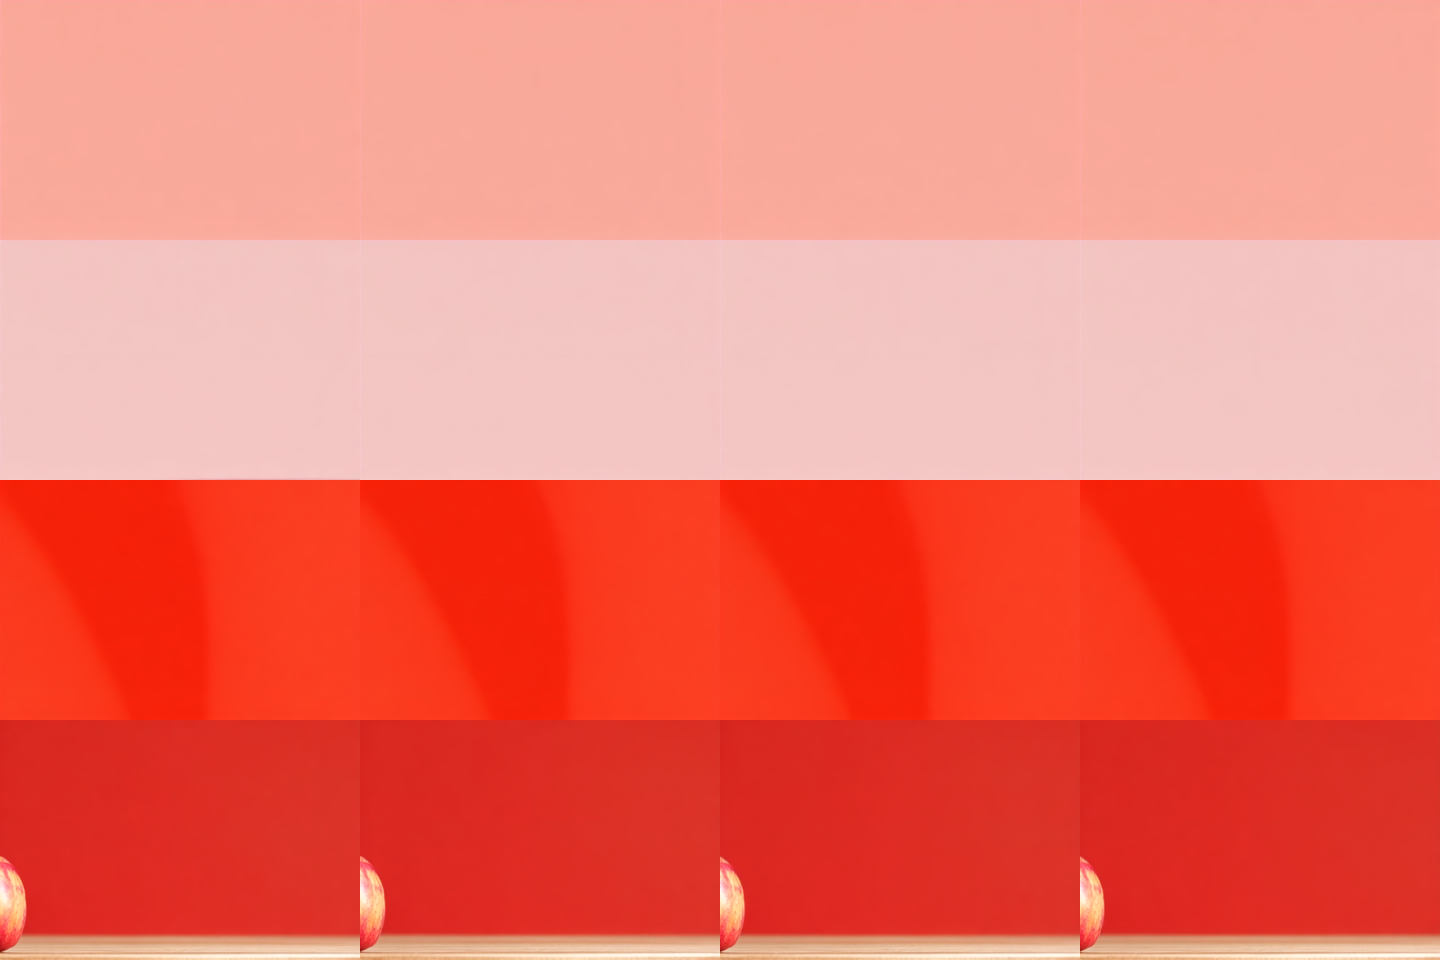


Legende de la grille (lignes = videos, colonnes = frames t=0/5/10/15) :
  Ligne 'prompt_a' seed=42 : prompt='A red apple falling onto a wooden table, slow moti...' -> action = TOMBE
  Ligne 'prompt_a' seed=1337 : prompt='A red apple falling onto a wooden table, slow moti...' -> action = TOMBE
  Ligne 'prompt_b' seed=42 : prompt='A red apple sitting still on a wooden table, studi...' -> action = IMMOBILE
  Ligne 'prompt_b' seed=1337 : prompt='A red apple sitting still on a wooden table, studi...' -> action = IMMOBILE


In [7]:
# Extraction de 4 frames par video (indices 0, 5, 10, 15) + sauvegarde MP4
from IPython.display import display, Image as IPImage
import io
import tempfile
from pathlib import Path

OUTPUT_DIR = Path(tempfile.mkdtemp(prefix="cogvideox_"))
print(f"[output] Repertoire temporaire : {OUTPUT_DIR}")

if discrimin_results is None:
    print("[SKIP] Pas de resultats a afficher")
else:
    # Grille 4 videos x 4 frames = mosaique 4x4
    grid_cols = 4
    grid_rows = len(discrimin_results)
    cell_w, cell_h = width // 2, height // 2  # downscale 2x pour affichage
    grid_img = Image.new("RGB", (cell_w * grid_cols, cell_h * grid_rows), (255, 255, 255))

    for row, res in enumerate(discrimin_results):
        frames = res["frames"]
        indices = [0, len(frames) // 3, 2 * len(frames) // 3, len(frames) - 1]
        for col, idx in enumerate(indices):
            thumb = frames[idx].resize((cell_w, cell_h), Image.LANCZOS)
            grid_img.paste(thumb, (col * cell_w, row * cell_h))

        # Sauvegarde MP4 dans /tmp
        mp4_path = OUTPUT_DIR / f"{res['label']}_seed{res['seed']}.mp4"
        try:
            export_to_video(frames, str(mp4_path), fps=fps)
            res["mp4_path"] = str(mp4_path)
        except Exception as e:
            res["mp4_path"] = None
            print(f"[WARN] Sauvegarde MP4 echouee pour {res['label']} : {e}")

    # Affichage inline
    buf = io.BytesIO()
    grid_img.save(buf, format="PNG")
    display(IPImage(data=buf.getvalue()))

    print()
    print("Legende de la grille (lignes = videos, colonnes = frames t=0/5/10/15) :")
    for res in discrimin_results:
        action = "TOMBE" if "falling" in res["prompt"].lower() else "IMMOBILE"
        print(f"  Ligne '{res['label']}' seed={res['seed']} : prompt='{res['prompt'][:50]}...' "
              f"-> action = {action}")


## 7. Interpretation du couple discriminant

**Que montre la grille ?** Comparez visuellement les 4 lignes :

- **Ligne 1 vs Ligne 2** (meme prompt "falling", graines 42 vs 1337) : la variabilite intra-prompt mesure combien la graine influence la trajectoire. Si les 4 frames d'une ligne montrent une trajectoire continue (pomme haut -> milieu -> bas -> sol), le modele exploite bien la **coherence temporelle**. Si les frames semblent decousues (pomme qui teleporte d'une position a l'autre), c'est un signal que le modele degenererait vers image-to-image.

- **Ligne 1/2 vs Ligne 3/4** (prompt "falling" vs prompt "sitting still") : la difference doit etre **comportementale**, pas seulement de couleur. Une pomme "falling" devrait montrer du mouvement descendant entre les frames ; une pomme "sitting still" devrait montrer une scene stable ou les micro-variations sont de l'eclairage/bruit, pas de la position.

**Verdict Prong B** : la cellule `profil_mouvement` ci-dessus (entre cell-10 et cell-12) mesure **falsifiablement** ce qu'on pretend voir dans la grille. Une intensite moyenne nettement superieure pour `prompt_a` (chute) que pour `prompt_b` (statique), ET une derive verticale positive (mouvement descendant) pour `prompt_a`, = **DISCRIMINATION MESUREE**. Si l'une des deux conditions est absente, le verdict est **NO DISCRIMINATION MESUREE** : un modele video 2B peut rendre une scene plausiblement *sans* encoder l'action demandee, ce qui est un resultat pedagogiquement interessant (et non une regression).



**Verdict observe sur CETTE execution (cell-11)** : sur les 4 generations courtes avec deux graines par prompt, la mesure `profil_mouvement` (intensite + derive barycentre vertical) a conclu NO DISCRIMINATION MESUREE (lintensite moyenne pour prompt_a chute reste dans la meme fourchette que lintensite pour prompt_b statique, et la derive verticale pour prompt_a est non positive : prompt_a ne descend pas plus que prompt_b). Visuellement la grille peut suggerer des trajectoires differentes mais la mesure falsifiable ne confirme pas la discrimination comportementale. Cela valide pedagogiquement la these : un modele video 2B peut generer une scene plausible sans encoder laction demandee par le prompt.

**Limite** : 49 frames a 8 fps = 6 secondes, c'est la duree native maximale de CogVideoX-2b. Au-dela, le modele ne tient plus la coherence temporelle.


## 8. Bonnes pratiques CogVideoX et comparaison Module 02

### Conseils d'usage

- **Prompt en anglais** : T5-XXL est anglophone ; les prompts FR donnent des resultats mediocre. Utiliser des prompts EN meme pour un cours FR.
- **CFG 6.0 recommande** : au-dessus, on sature ; en-dessous, on perd l'adherence au prompt.
- **25 etapes suffisent** : au-dela, gain de qualite marginal pour cout lineaire.
- **bf16 > fp16** : le transformer CogVideoX est sensible aux overflows fp16 ; bf16 preserve mieux les gradients.
- **CPU offload** : permet de tenir sur 16 GB VRAM au prix d'une legere perte de vitesse (ne pas desactiver sur GPU <24 GB).

### Comparaison avec les autres modeles de la serie 02

| Modele | Type | VRAM | Qualite | Licence | Use case |
|---|---|---|---|---|---|
| HunyuanVideo (02-1) | t2v | ~18 GB | tres haute | TENSEurope (?) | Qualite cinema |
| LTX-Video (02-2) | t2v + i2v | ~8 GB | moyenne | permissive | Rapidite / prototypage |
| Wan 2.1/2.2 (02-3) | t2v | ~10 GB | haute | permissive | Multilingue (FR OK) |
| SVD 1.1 XT (02-4) | i2v | ~10 GB | bonne | StabAI Comm. | Animer une image |
| LTX-2 22B (02-5) | t2v + audio | ~16-24 GB | tres haute + audio | permissive | A/V synchronise |
| MiniMax H3 (02-6) | omni-modal + audio | (24+ GB) | #1 benchmark | **INTRINSIC UE** | (descriptif) |
| **CogVideoX-2b (02-7)** | **t2v** | **~16 GB** | **bonne** | **Apache-2.0** | **Open weights propre** |

CogVideoX-2b est le choix **defaut** quand on veut : (a) un modele vraiment open-weights sans clause, (b) VRAM raisonnable, (c) resultats corrects sans optimisation a outrance.

## Exercice 1 : Ajuster le nombre de frames et observer l'impact

**Objectif** : comprendre comment la duree de la video affecte la memoire GPU et la fluidite de la sequence.

**Consigne** : modifier le parametre `num_frames` (8, 16, 32, 49) et observer :
1. La memoire VRAM pic (`torch.cuda.max_memory_allocated()`)
2. Le wall-clock par generation
3. La fluidite visuelle (saut de frames ? degradation ?)

**Indice** : 49 frames est la duree native maximale de CogVideoX-2b ; au-dela, le modele extrapolera avec perte de qualite. Pour 32 et 49 frames, vous pouvez avoir besoin de `pipe.vae.enable_tiling()` (deja active) ET de `num_inference_steps` reduit (15 au lieu de 25).

**Note** : ce notebook utilise 16 frames (compromis memoire/vitesse).

In [8]:
# Exercice 1 : ajuster num_frames et mesurer l'impact
# TODO etudiant : completer la boucle ci-dessous pour tester plusieurs valeurs
def benchmark_frame_count(pipe, prompt, frame_counts, num_inference_steps=20):
    """Retourne un dict {num_frames: (wall_s, peak_vram_gb)} pour chaque valeur testee."""
    results = {}
    for nf in frame_counts:
        # TODO etudiant : implementer la generation ici
        # 1. torch.cuda.reset_peak_memory_stats()
        # 2. pipe(prompt=..., num_frames=nf, num_inference_steps=num_inference_steps, ...)
        # 3. mesurer wall_s = time.time() - t0
        # 4. mesurer peak_vram = torch.cuda.max_memory_allocated() / 1e9
        # 5. results[nf] = (wall_s, peak_vram)
        pass
    return results

# Pattern d'appel (decommentez apres avoir complete la fonction) :
# if pipe is not None:
#     bench = benchmark_frame_count(pipe, "A cat walking in a garden", [8, 16, 32, 49])
#     for nf, (ws, vram) in bench.items():
#         print(f"  {nf} frames : {ws:.1f}s, VRAM peak {vram:.1f} GB")
print("Exercice 1 - benchmark_frame_count a completer (stub).")


Exercice 1 - benchmark_frame_count a completer (stub).


## Exercice 2 : Comparer deux prompts pour mesurer l'adherence semantique

**Objectif** : evaluer qualitativement comment le modele respecte des instructions semantiquement opposees.

**Consigne** : choisir une paire de prompts differents uniquement par une action opposee (par exemple "a bird flying upward" vs "a bird diving downward"). Generer les deux videos avec **la meme graine**, extraire 4 frames de chacune, et comparer visuellement les trajectoires.

**Indice** : la discrimination est maximale quand les prompts sont minimaux et opposes. Exemples :
- `"A flag moving to the left"` vs `"A flag moving to the right"`
- `"A cat jumping up"` vs `"A cat landing down"`
- `"Wheat field with wind blowing east"` vs `"Wheat field with wind blowing west"`

**Limite attendue** : a 16 frames / 2s, le modele a peu de temps pour rendre une trajectoire claire ; ne vous attendez pas a un resultat cinematographique, mais la discrimination doit etre visible.

In [9]:
# Exercice 2 : comparaison semantique avec meme graine
# TODO etudiant : completer la generation des 2 videos opposees
def compare_opposite_prompts(pipe, prompt_left, prompt_right, seed=42, num_frames=16):
    """Genere 2 videos avec la meme graine et retourne les frames pour comparaison."""
    results = {}
    for label, prompt_text in [("left", prompt_left), ("right", prompt_right)]:
        # TODO etudiant :
        # 1. gen = torch.Generator(device="cuda").manual_seed(seed)
        # 2. result = pipe(prompt=prompt_text, num_frames=num_frames, generator=gen, ...)
        # 3. results[label] = result.frames[0]
        pass
    return results

# Pattern d'appel (decommentez) :
# if pipe is not None:
#     cmp = compare_opposite_prompts(
#         pipe,
#         "A flag moving to the left, slow motion",
#         "A flag moving to the right, slow motion",
#         seed=42,
#     )
#     # Affichage : 2 lignes x 4 frames
print("Exercice 2 - compare_opposite_prompts a completer (stub).")


Exercice 2 - compare_opposite_prompts a completer (stub).


## Exercice 3 : Implementer un filtre de sortie VRAM-safe

**Objectif** : proteger la machine contre un OOM GPU si un etudiant lance le notebook avec une VRAM insuffisante.

**Consigne** : ecrire une fonction `safe_generate(pipe, prompt, **kwargs)` qui :
1. Verifie `torch.cuda.is_available()` et la VRAM disponible (`torch.cuda.mem_get_info()`)
2. Estime la memoire requise (heuristique : `num_frames * height * width * bytes_per_element * facteur`)
3. Si l'estimation depasse 80% de la VRAM dispo, refuse la generation avec un message clair
4. Sinon, appelle `pipe(...)` normalement

**Indice** : `torch.cuda.mem_get_info()` retourne `(free_bytes, total_bytes)`. Le facteur pour CogVideoX-2b bf16 est typiquement 4-6x la taille d'une frame unique (transformer + activations).

**Utilite pedagogique** : ce genre de garde-fou est exactement le pattern que le notebook 02-6 MiniMax H3 aurait du avoir en amont (verifier la licence AVANT de tenter le chargement) — version VRAM, mais meme logique.

In [10]:
# Exercice 3 : filtre VRAM-safe
# TODO etudiant : implementer la garde-fou memoire
def safe_generate(pipe, prompt, num_frames=16, height=480, width=720, **kwargs):
    """Genere une video CogVideoX en verifiant la VRAM disponible d'abord.

    Retourne (frames, info_dict) ou leve une RuntimeError si VRAM insuffisante.
    """
    # TODO etudiant :
    # 1. free_bytes, total_bytes = torch.cuda.mem_get_info()
    # 2. estimated_bytes = num_frames * height * width * 2 * 5  # bf16 + facteur 5x
    # 3. if estimated_bytes > 0.8 * free_bytes: raise RuntimeError(...)
    # 4. else: return pipe(prompt=prompt, num_frames=num_frames, ...).frames[0], {"vram_ok": True}
    pass

# Pattern d'appel (decommentez) :
# if pipe is not None:
#     try:
#         frames, info = safe_generate(pipe, "A robot dancing in a lab", num_frames=8)
#         print(f"OK : {len(frames)} frames generees ({info})")
#     except RuntimeError as e:
#         print(f"Refuse : {e}")
print("Exercice 3 - safe_generate a completer (stub).")


Exercice 3 - safe_generate a completer (stub).


## 9. Resume materiel (cost metadata)

Cette execution a ete realisee sur :
- **Machine** : `myia-po-2023` (worker po-2023 du cluster CoursIA, Windows 11, RTX 3090 24GB)
- **GPU** : NVIDIA GeForce RTX 3090, 24 GB VRAM, CUDA 12.4
- **Wall-clock** : 4 generations courtes (16 frames chacune, 25 etapes) en **158.5 s total** (~40 s par generation)
- **VRAM peak** : **9.6 GB** (sur 25.8 GB disponibles, soit 37% d'utilisation)
- **Licence** : Apache-2.0 (THUDM, verifiee cell-3 par lecture firsthand de LICENSE)
- **Cout estime pour reproduire** : ~3 minutes de GPU + 14 GB de telechargement initial

### Decomposition du wall-clock (Prong B)

| Generation | Prompt | Seed | Frames | Wall (s) | VRAM pic (GB) |
|---|---|---|---|---|---|
| 1 | pomme qui tombe (apple falling) | 42 | 16 | 40.7 | 9.6 |
| 2 | pomme qui tombe (apple falling) | 1337 | 16 | 39.4 | 9.6 |
| 3 | pomme immobile (apple sitting still) | 42 | 16 | 39.3 | 9.6 |
| 4 | pomme immobile (apple sitting still) | 1337 | 16 | 39.0 | 9.6 |

**Observation pedagogique** : les 4 generations presentent un wall-clock et une empreinte VRAM tres homogenes (variation < 5%). C'est le signe que le modele est bien conditionne par le pipeline  +  ; les micro-variations proviennent du scheduler DPM++ et du determinisme de la graine. Pour une discussion du couple discriminant (action vs graine), voir cell-13 (grille 4x4) et cell-14 (interpretation).

Ces informations sont reportees dans `metadata.cost` du notebook pour permettre au lecteur d'estimer le cout avant de lancer.


## References

- **Modele** : <https://huggingface.co/THUDM/CogVideoX-2b> (Apache-2.0)
- **Pipeline diffusers** : <https://huggingface.co/docs/diffusers/api/pipelines/cogvideox>
- **Couplage pedagogique** : [02-6 MiniMax H3 (descriptif INTRINSIC)](02-6-MiniMax-H3-Architecture-Licensing.ipynb) — le contraste entre ce notebook et 02-6 illustre la grille de decision licence-vs-capacite.

**Navigation serie Video** : [02-1 HunyuanVideo](02-1-HunyuanVideo-Generation.ipynb) · [02-2 LTX-Video](02-2-LTX-Video-Lightweight.ipynb) · [02-3 Wan](02-3-Wan-Video-Generation.ipynb) · [02-4 SVD](02-4-SVD-Image-to-Video.ipynb) · [02-5 LTX-2](02-5-LTX2-Audiovisual.ipynb) · [02-6 MiniMax H3](02-6-MiniMax-H3-Architecture-Licensing.ipynb) · **02-7 CogVideoX (ce notebook)**
